# 06 Module Scoring

Input gene modules, score them on the annotated CD8 object, and plot module scores by cluster or condition. The scoring object is rebuilt from `layers["counts"]` so scores use log-normalized expression rather than scaled PCA input.


In [1]:
import sys
sys.path.append("/home/dk5299/Projects_31926/RNA-seq/Kallies_Sci_Immuno_2025")

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc

from src.paths import INTERMEDIATE_DIR, RESULTS_DIR

sc.settings.verbosity = 3
sc.settings.set_figure_params(dpi=100, facecolor="white")


/tmp/ipykernel_3918122/3567259375.py:15: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor="white")


## Inputs

Edit `modules` directly, or set `module_file` to a CSV with columns `module` and `gene`. Use `groupby` to switch plots between clusters and conditions, for example `"leiden_0_5"` or `"condition"`.


In [51]:
input_file = INTERMEDIATE_DIR / "04_cell_annotation.h5ad"
output_prefix = "06_module_scores"

# Optional CSV with columns: module,gene. Leave as None to use the dictionary below.
module_file = None

modules = {
    "t_cell_core": ["Cd3d", "Cd3e", "Trac", "Lck", "Lat"],
    "cd8_core": ["Cd8a", "Cd8b1"],
    "cytotoxic": ["Nkg7", "Gzmb", "Gzma", "Prf1", "Ccl5", "Ctsw"],
    "effector_inflammatory": ["Ifng", "Tnf", "Il2ra", "Cxcr3", "Irf1"],
    "memory_like": ["Tcf7", "Lef1", "Il7r", "Sell", "Ccr7", "Bcl2"],
    "tissue_residency": ["Itgae", "Cd69", "Cxcr6", "Zfp683", "Rgs1"],
    "activation_exhaustion": ["Pdcd1", "Lag3", "Tigit", "Havcr2", "Ctla4", "Tox"],
    "proliferation": ["Mki67", "Top2a", "Stmn1", "Tubb5", "Hmgb2"],
    "interferon_response": ["Isg15", "Ifit1", "Ifit3", "Irf7", "Stat1", "Bst2"],
    "trafficking": ["S1pr1", "Klf2", "S1pr5", "Ccr7"],
    "strong_renetion": ["Itgae", "Itga1", "Cd69", "Ccr9", "Cxcr6", "Jaml", "Cd160", "Zfp683", "Prdm1", "Runx3", "Ahr", "Bhlhe40", "Rora", "Tgfbr1", "Tgfbr2", "Il2rb", "Bcl2"],
    "psoriasis": ["Il17a", "Il17f", "Ccl20", "Il22", "Il23r", "Il26", "Cxcl13", "Tnf", "Ifng", "Cd69", "Itgae", "Cxcr6", "Ccr8"]
}

# Choose one of: "condition", "sample_group", "leiden_0_5".
groupby = "condition"

# Scores are also summarized for every column listed here when present.
summary_groupbys = ["condition", "sample_group", "leiden_0_5"]


In [52]:
def safe_name(value):
    cleaned = re.sub(r"[^0-9A-Za-z]+", "_", str(value).strip()).strip("_").lower()
    if not cleaned:
        raise ValueError(f"Invalid empty name from {value!r}")
    return cleaned


def load_modules(module_file, modules):
    if module_file is None:
        return modules

    module_df = pd.read_csv(module_file)
    required = {"module", "gene"}
    missing = required.difference(module_df.columns)
    if missing:
        raise ValueError(f"{module_file} is missing required column(s): {sorted(missing)}")

    loaded = {}
    for module, gene_df in module_df.dropna(subset=["module", "gene"]).groupby("module"):
        genes = [str(gene).strip() for gene in gene_df["gene"] if str(gene).strip()]
        loaded[str(module)] = list(dict.fromkeys(genes))
    return loaded


modules = load_modules(module_file, modules)
modules


{'t_cell_core': ['Cd3d', 'Cd3e', 'Trac', 'Lck', 'Lat'],
 'cd8_core': ['Cd8a', 'Cd8b1'],
 'cytotoxic': ['Nkg7', 'Gzmb', 'Gzma', 'Prf1', 'Ccl5', 'Ctsw'],
 'effector_inflammatory': ['Ifng', 'Tnf', 'Il2ra', 'Cxcr3', 'Irf1'],
 'memory_like': ['Tcf7', 'Lef1', 'Il7r', 'Sell', 'Ccr7', 'Bcl2'],
 'tissue_residency': ['Itgae', 'Cd69', 'Cxcr6', 'Zfp683', 'Rgs1'],
 'activation_exhaustion': ['Pdcd1', 'Lag3', 'Tigit', 'Havcr2', 'Ctla4', 'Tox'],
 'proliferation': ['Mki67', 'Top2a', 'Stmn1', 'Tubb5', 'Hmgb2'],
 'interferon_response': ['Isg15', 'Ifit1', 'Ifit3', 'Irf7', 'Stat1', 'Bst2'],
 'trafficking': ['S1pr1', 'Klf2', 'S1pr5', 'Ccr7'],
 'strong_renetion': ['Itgae',
  'Itga1',
  'Cd69',
  'Ccr9',
  'Cxcr6',
  'Jaml',
  'Cd160',
  'Zfp683',
  'Prdm1',
  'Runx3',
  'Ahr',
  'Bhlhe40',
  'Rora',
  'Tgfbr1',
  'Tgfbr2',
  'Il2rb',
  'Bcl2'],
 'psoriasis': ['Il17a',
  'Il17f',
  'Ccl20',
  'Il22',
  'Il23r',
  'Il26',
  'Cxcl13',
  'Tnf',
  'Ifng',
  'Cd69',
  'Itgae',
  'Cxcr6',
  'Ccr8']}

## Load and Prepare Expression


In [53]:
adata = sc.read_h5ad(input_file)
adata


AnnData object with n_obs × n_vars = 13206 × 16263
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'hash_id', 'hto_max', 'hto_second', 'hto_top_to_second_ratio', 'hto_total', 'sample_group', 'man_2025_group', 'demux_call', 'hto_HT1', 'hto_HT2', 'hto_HT3', 'leiden_0_5', 'cell_type_manual', 'cd8_subset'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'cell_type_manual_colors', 'hash_id_colors', 'hvg', 'leiden_0_5', 'leiden_0_5_colors', 'log1p', 'neighbors', 'pca', 'rank_genes_groups

In [54]:
if "sample_group" in adata.obs:
    adata.obs["condition"] = adata.obs["sample_group"].map(
        {
            "sIEL": "IEL_memory",
            "sLPL": "LPL_memory",
            "rechallenge": "rechallenge",
        }
    ).fillna(adata.obs["sample_group"].astype(str))

    condition_order = ["IEL_memory", "LPL_memory", "rechallenge"]
    present_conditions = [condition for condition in condition_order if condition in set(adata.obs["condition"])]
    adata.obs["condition"] = pd.Categorical(
        adata.obs["condition"],
        categories=present_conditions,
        ordered=True,
    )

adata.obs[[col for col in ["sample_group", "condition", "leiden_0_5"] if col in adata.obs]].head()


,sample_group,condition,leiden_0_5
AAACCCAAGTCAAGCG-1,sLPL,LPL_memory,5
AAACCCACAATAAGGT-1,rechallenge,rechallenge,0
AAACCCACAGCCCACA-1,sIEL,IEL_memory,6
AAACCCACATACTTTC-1,sIEL,IEL_memory,2
AAACCCACATAGTCGT-1,sIEL,IEL_memory,2


In [55]:
score_adata = adata.copy()

if "counts" in score_adata.layers:
    score_adata.X = score_adata.layers["counts"].copy()
elif "raw_counts" in score_adata.layers:
    score_adata.X = score_adata.layers["raw_counts"].copy()
else:
    print("WARNING: no count layer found; using current .X for scoring")

score_adata.uns.pop("log1p", None)
sc.pp.normalize_total(score_adata, target_sum=1e4)
sc.pp.log1p(score_adata)

score_adata


normalizing counts per cell
    finished (0:00:00)


AnnData object with n_obs × n_vars = 13206 × 16263
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'n_genes', 'hash_id', 'hto_max', 'hto_second', 'hto_top_to_second_ratio', 'hto_total', 'sample_group', 'man_2025_group', 'demux_call', 'hto_HT1', 'hto_HT2', 'hto_HT3', 'leiden_0_5', 'cell_type_manual', 'cd8_subset', 'condition'
    var: 'gene_ids', 'feature_types', 'mt', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'highly_variable_nbatches', 'highly_variable_intersection', 'mean', 'std'
    uns: 'cell_type_manual_colors', 'hash_id_colors', 'hvg', 'leiden_0_5', 'leiden_0_5_colors', 'neighbors', 'pca', 'rank_genes_gr

## Score Modules


In [56]:
score_columns = []
coverage_rows = []

for module, genes in modules.items():
    score_column = f"module_score_{safe_name(module)}"
    genes_present = [gene for gene in genes if gene in score_adata.var_names]
    genes_missing = sorted(set(genes).difference(genes_present))

    coverage_rows.append(
        {
            "module": module,
            "score_column": score_column,
            "n_genes_requested": len(genes),
            "n_genes_present": len(genes_present),
            "n_genes_missing": len(genes_missing),
            "genes_present": ";".join(genes_present),
            "genes_missing": ";".join(genes_missing),
        }
    )

    if len(genes_present) < 2:
        print(f"Skipping {module}: fewer than 2 genes present ({len(genes_present)}/{len(genes)})")
        continue

    sc.tl.score_genes(
        score_adata,
        gene_list=genes_present,
        score_name=score_column,
        ctrl_size=50,
        random_state=0,
        use_raw=False,
    )
    score_columns.append(score_column)

coverage = pd.DataFrame(coverage_rows)
coverage


computing score 'module_score_t_cell_core'
    finished: added
    'module_score_t_cell_core', score of gene set (adata.obs).
    50 total control genes are used. (0:00:00)
computing score 'module_score_cd8_core'
    finished: added
    'module_score_cd8_core', score of gene set (adata.obs).
    50 total control genes are used. (0:00:00)
computing score 'module_score_cytotoxic'
    finished: added
    'module_score_cytotoxic', score of gene set (adata.obs).
    100 total control genes are used. (0:00:00)
computing score 'module_score_effector_inflammatory'
    finished: added
    'module_score_effector_inflammatory', score of gene set (adata.obs).
    199 total control genes are used. (0:00:00)
computing score 'module_score_memory_like'
    finished: added
    'module_score_memory_like', score of gene set (adata.obs).
    199 total control genes are used. (0:00:00)
computing score 'module_score_tissue_residency'
    finished: added
    'module_score_tissue_residency', score of gene set

,module,score_column,n_genes_requested,n_genes_present,n_genes_missing,genes_present,genes_missing
0,t_cell_core,module_score_t_cell_core,5,5,0,Cd3d;Cd3e;Trac;Lck;Lat,
1,cd8_core,module_score_cd8_core,2,2,0,Cd8a;Cd8b1,
2,cytotoxic,module_score_cytotoxic,6,6,0,Nkg7;Gzmb;Gzma;Prf1;Ccl5;Ctsw,
3,effector_inflammatory,module_score_effector_inflammatory,5,5,0,Ifng;Tnf;Il2ra;Cxcr3;Irf1,
4,memory_like,module_score_memory_like,6,6,0,Tcf7;Lef1;Il7r;Sell;Ccr7;Bcl2,
5,tissue_residency,module_score_tissue_residency,5,5,0,Itgae;Cd69;Cxcr6;Zfp683;Rgs1,
6,activation_exhaustion,module_score_activation_exhaustion,6,6,0,Pdcd1;Lag3;Tigit;Havcr2;Ctla4;Tox,
7,proliferation,module_score_proliferation,5,5,0,Mki67;Top2a;Stmn1;Tubb5;Hmgb2,
8,interferon_response,module_score_interferon_response,6,6,0,Isg15;Ifit1;Ifit3;Irf7;Stat1;Bst2,
9,trafficking,module_score_trafficking,4,4,0,S1pr1;Klf2;S1pr5;Ccr7,


## Save Score Tables


In [8]:
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

coverage_file = RESULTS_DIR / f"{output_prefix}_module_gene_coverage.csv"
coverage.to_csv(coverage_file, index=False)
print("Saved:", coverage_file)

metadata_columns = [col for col in ["sample_group", "condition", "hash_id", "demux_call", "leiden_0_5", "cell_type_manual"] if col in score_adata.obs]
cell_scores = score_adata.obs[metadata_columns + score_columns].copy()

cell_scores_file = RESULTS_DIR / f"{output_prefix}_cell_scores.csv"
cell_scores.to_csv(cell_scores_file, index=True, index_label="barcode")
print("Saved:", cell_scores_file)

cell_scores.head()


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_module_scores_module_gene_coverage.csv


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_module_scores_cell_scores.csv


,sample_group,condition,hash_id,demux_call,leiden_0_5,cell_type_manual,module_score_t_cell_core,module_score_cd8_core,module_score_cytotoxic,module_score_effector_inflammatory,module_score_memory_like,module_score_tissue_residency,module_score_activation_exhaustion,module_score_proliferation,module_score_interferon_response,module_score_trafficking
AAACCCAAGTCAAGCG-1,sLPL,LPL_memory,HT2,Singlet,5,CD8 T cell,0.458744,0.646633,0.962827,-0.589358,-0.042466,0.279597,-0.158934,0.282634,-0.565757,-0.147617
AAACCCACAATAAGGT-1,rechallenge,rechallenge,Negative,Singlet,0,CD8 T cell,0.397832,1.130277,1.290876,-0.008221,-0.290205,1.105470,0.055087,-0.382009,0.147301,-0.048166
AAACCCACAGCCCACA-1,sIEL,IEL_memory,HT1,Singlet,6,CD8 T cell,0.375063,0.208661,1.429679,-0.255276,0.122662,1.140230,0.025751,0.162572,0.355118,-0.061925
AAACCCACATACTTTC-1,sIEL,IEL_memory,HT1,Singlet,2,CD8 T cell,0.619905,0.705853,0.733835,-0.189128,0.168843,0.892495,0.059182,-0.178592,-0.149724,-0.236474
AAACCCACATAGTCGT-1,sIEL,IEL_memory,HT1,Singlet,2,CD8 T cell,0.467725,0.488379,1.369985,-0.256811,-0.027847,0.993318,-0.250134,0.153271,-0.604638,0.071323


In [9]:
summary_tables = {}

for group in summary_groupbys:
    if group not in score_adata.obs:
        continue

    summary = (
        score_adata.obs.groupby(group, observed=True)[score_columns]
        .agg(["mean", "median", "std"])
        .reset_index()
    )
    summary.columns = [
        "_".join(str(part) for part in col if part) if isinstance(col, tuple) else col
        for col in summary.columns
    ]
    summary["n_cells"] = summary[group].map(score_adata.obs[group].value_counts())
    summary_tables[group] = summary

    summary_file = RESULTS_DIR / f"{output_prefix}_by_{safe_name(group)}.csv"
    summary.to_csv(summary_file, index=False)
    print("Saved:", summary_file)

summary_tables


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_module_scores_by_condition.csv
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_module_scores_by_sample_group.csv
Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_module_scores_by_leiden_0_5.csv


{'condition':      condition  module_score_t_cell_core_mean  \
 0   IEL_memory                       0.377932   
 1   LPL_memory                       0.470864   
 2  rechallenge                       0.288055   
 
    module_score_t_cell_core_median  module_score_t_cell_core_std  \
 0                         0.389358                      0.340030   
 1                         0.484632                      0.308891   
 2                         0.296188                      0.352799   
 
    module_score_cd8_core_mean  module_score_cd8_core_median  \
 0                    0.660326                      0.693826   
 1                    0.761846                      0.800954   
 2                    0.408057                      0.465360   
 
    module_score_cd8_core_std  module_score_cytotoxic_mean  \
 0                   0.518226                     1.054121   
 1                   0.469974                     1.201064   
 2                   0.571203                     0.915756   
 

## Plot on UMAP


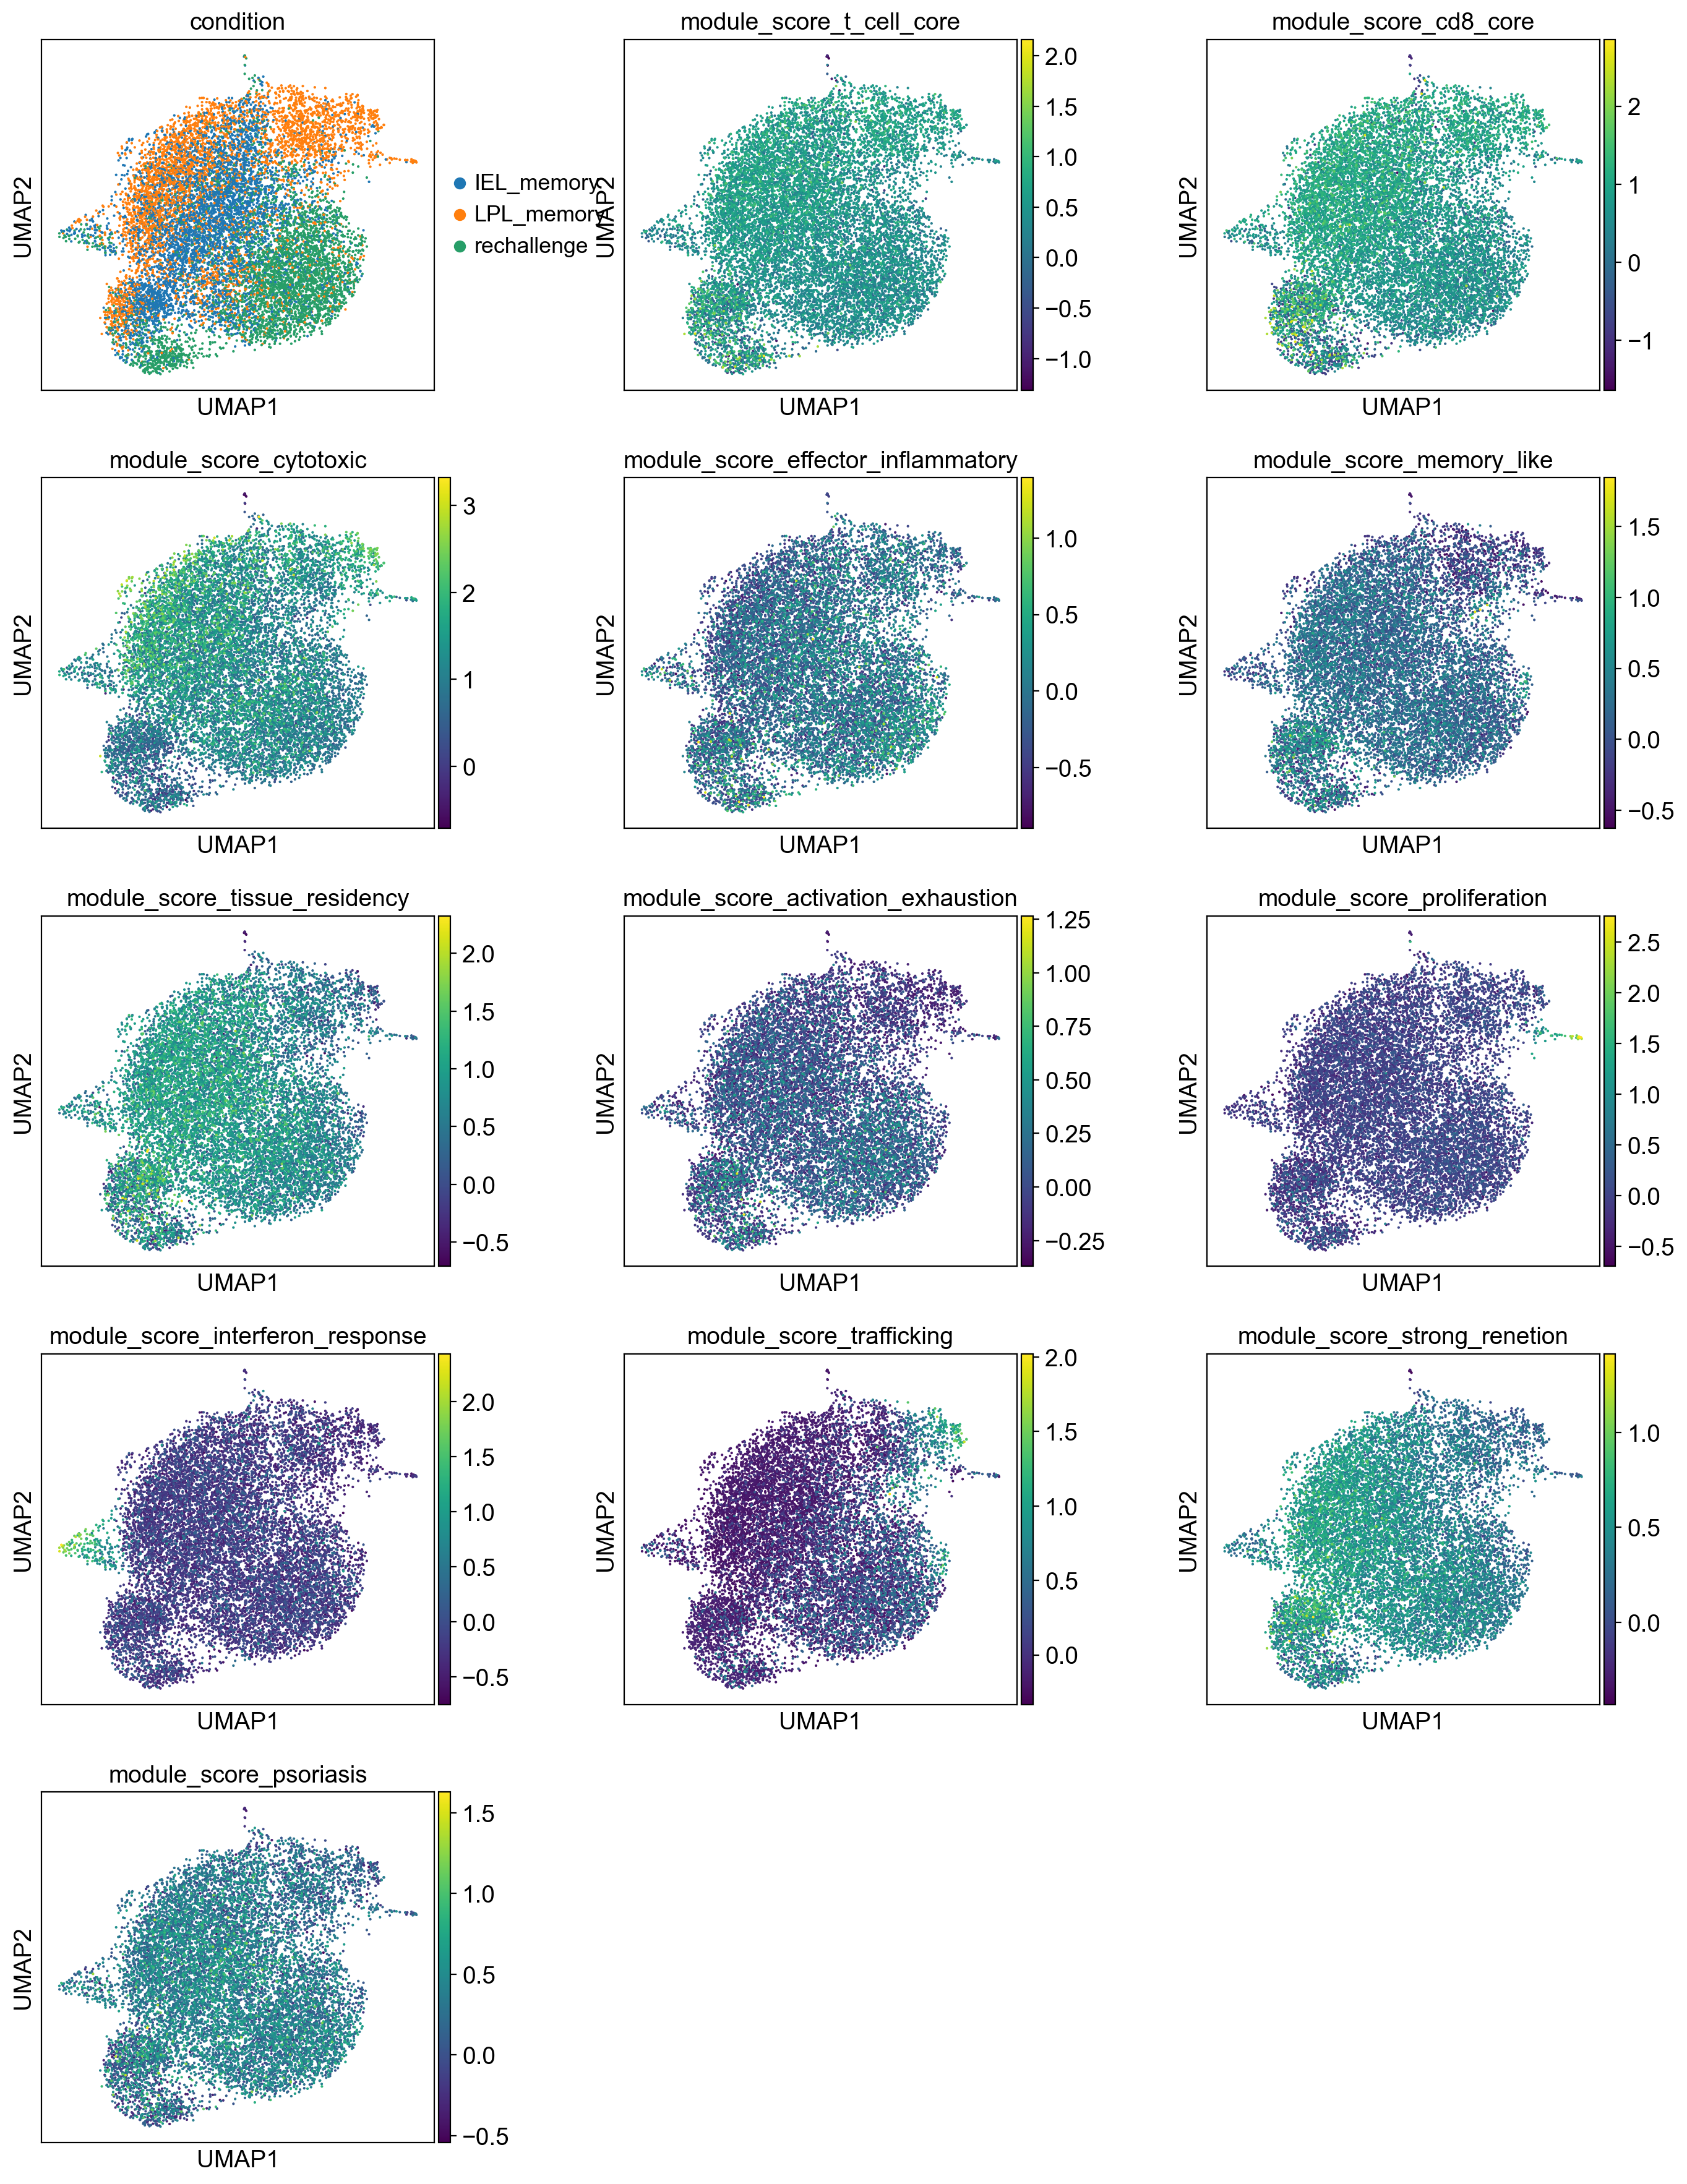

In [57]:
if "X_umap" in score_adata.obsm:
    sc.pl.umap(
        score_adata,
        color=[col for col in [groupby] + score_columns if col in score_adata.obs],
        wspace=0.35,
        ncols=3,
    )


## Plot by Cluster or Condition

Change `groupby` in the input cell, then rerun from here to switch between `condition`, `sample_group`, and `leiden_0_5`.


In [58]:
def module_score_matrix(adata, score_columns, groupby):
    if groupby not in adata.obs:
        raise ValueError(f"{groupby!r} is not an obs column")

    matrix = adata.obs.groupby(groupby, observed=True)[score_columns].mean()
    matrix.columns = [col.replace("module_score_", "") for col in matrix.columns]
    return matrix


score_matrix = module_score_matrix(score_adata, score_columns, groupby)
score_matrix


,t_cell_core,cd8_core,cytotoxic,effector_inflammatory,memory_like,tissue_residency,activation_exhaustion,proliferation,interferon_response,trafficking,strong_renetion,psoriasis
condition,,,,,,,,,,,,
IEL_memory,0.377932,0.660326,1.054121,-0.174354,0.150048,0.749390,0.006994,-0.083805,-0.214097,-0.054805,0.430389,0.286915
LPL_memory,0.470864,0.761846,1.201064,-0.174680,0.078876,0.648171,-0.042335,-0.059011,-0.246330,-0.027878,0.396293,0.260937
rechallenge,0.288055,0.408057,0.915756,-0.107535,0.119243,0.578164,0.060141,-0.035909,-0.198607,0.063009,0.312132,0.245119


Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_module_scores_heatmap_by_condition.png


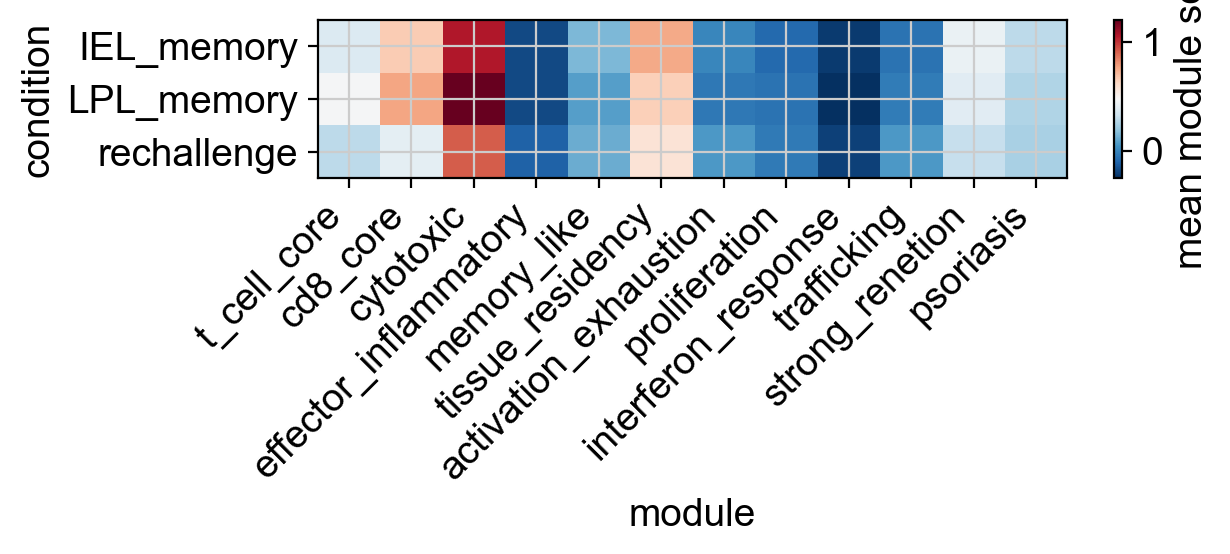

In [59]:
fig_width = max(6, 0.55 * score_matrix.shape[1])
fig_height = max(3, 0.45 * score_matrix.shape[0])

fig, ax = plt.subplots(figsize=(fig_width, fig_height))
im = ax.imshow(score_matrix.values, aspect="auto", cmap="RdBu_r")

ax.set_xticks(np.arange(score_matrix.shape[1]))
ax.set_xticklabels(score_matrix.columns, rotation=45, ha="right")
ax.set_yticks(np.arange(score_matrix.shape[0]))
ax.set_yticklabels(score_matrix.index.astype(str))
ax.set_xlabel("module")
ax.set_ylabel(groupby)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("mean module score")

fig.tight_layout()
heatmap_file = RESULTS_DIR / f"{output_prefix}_heatmap_by_{safe_name(groupby)}.png"
fig.savefig(heatmap_file, dpi=300, bbox_inches="tight")
print("Saved:", heatmap_file)


/tmp/ipykernel_3918122/3091576957.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[str(group) for group in groups], showfliers=False)
/tmp/ipykernel_3918122/3091576957.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[str(group) for group in groups], showfliers=False)
/tmp/ipykernel_3918122/3091576957.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(values, labels=[str(group) for group in groups], showfliers=False)
/tmp/ipykernel_3918122/3091576957.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_

Saved: /mnt/sata4/Dhruv_2025/Projects_31926/RNA_Seq/Kallies_Sci_Immuno_2025/results/06_module_scores_boxplots_by_condition.png


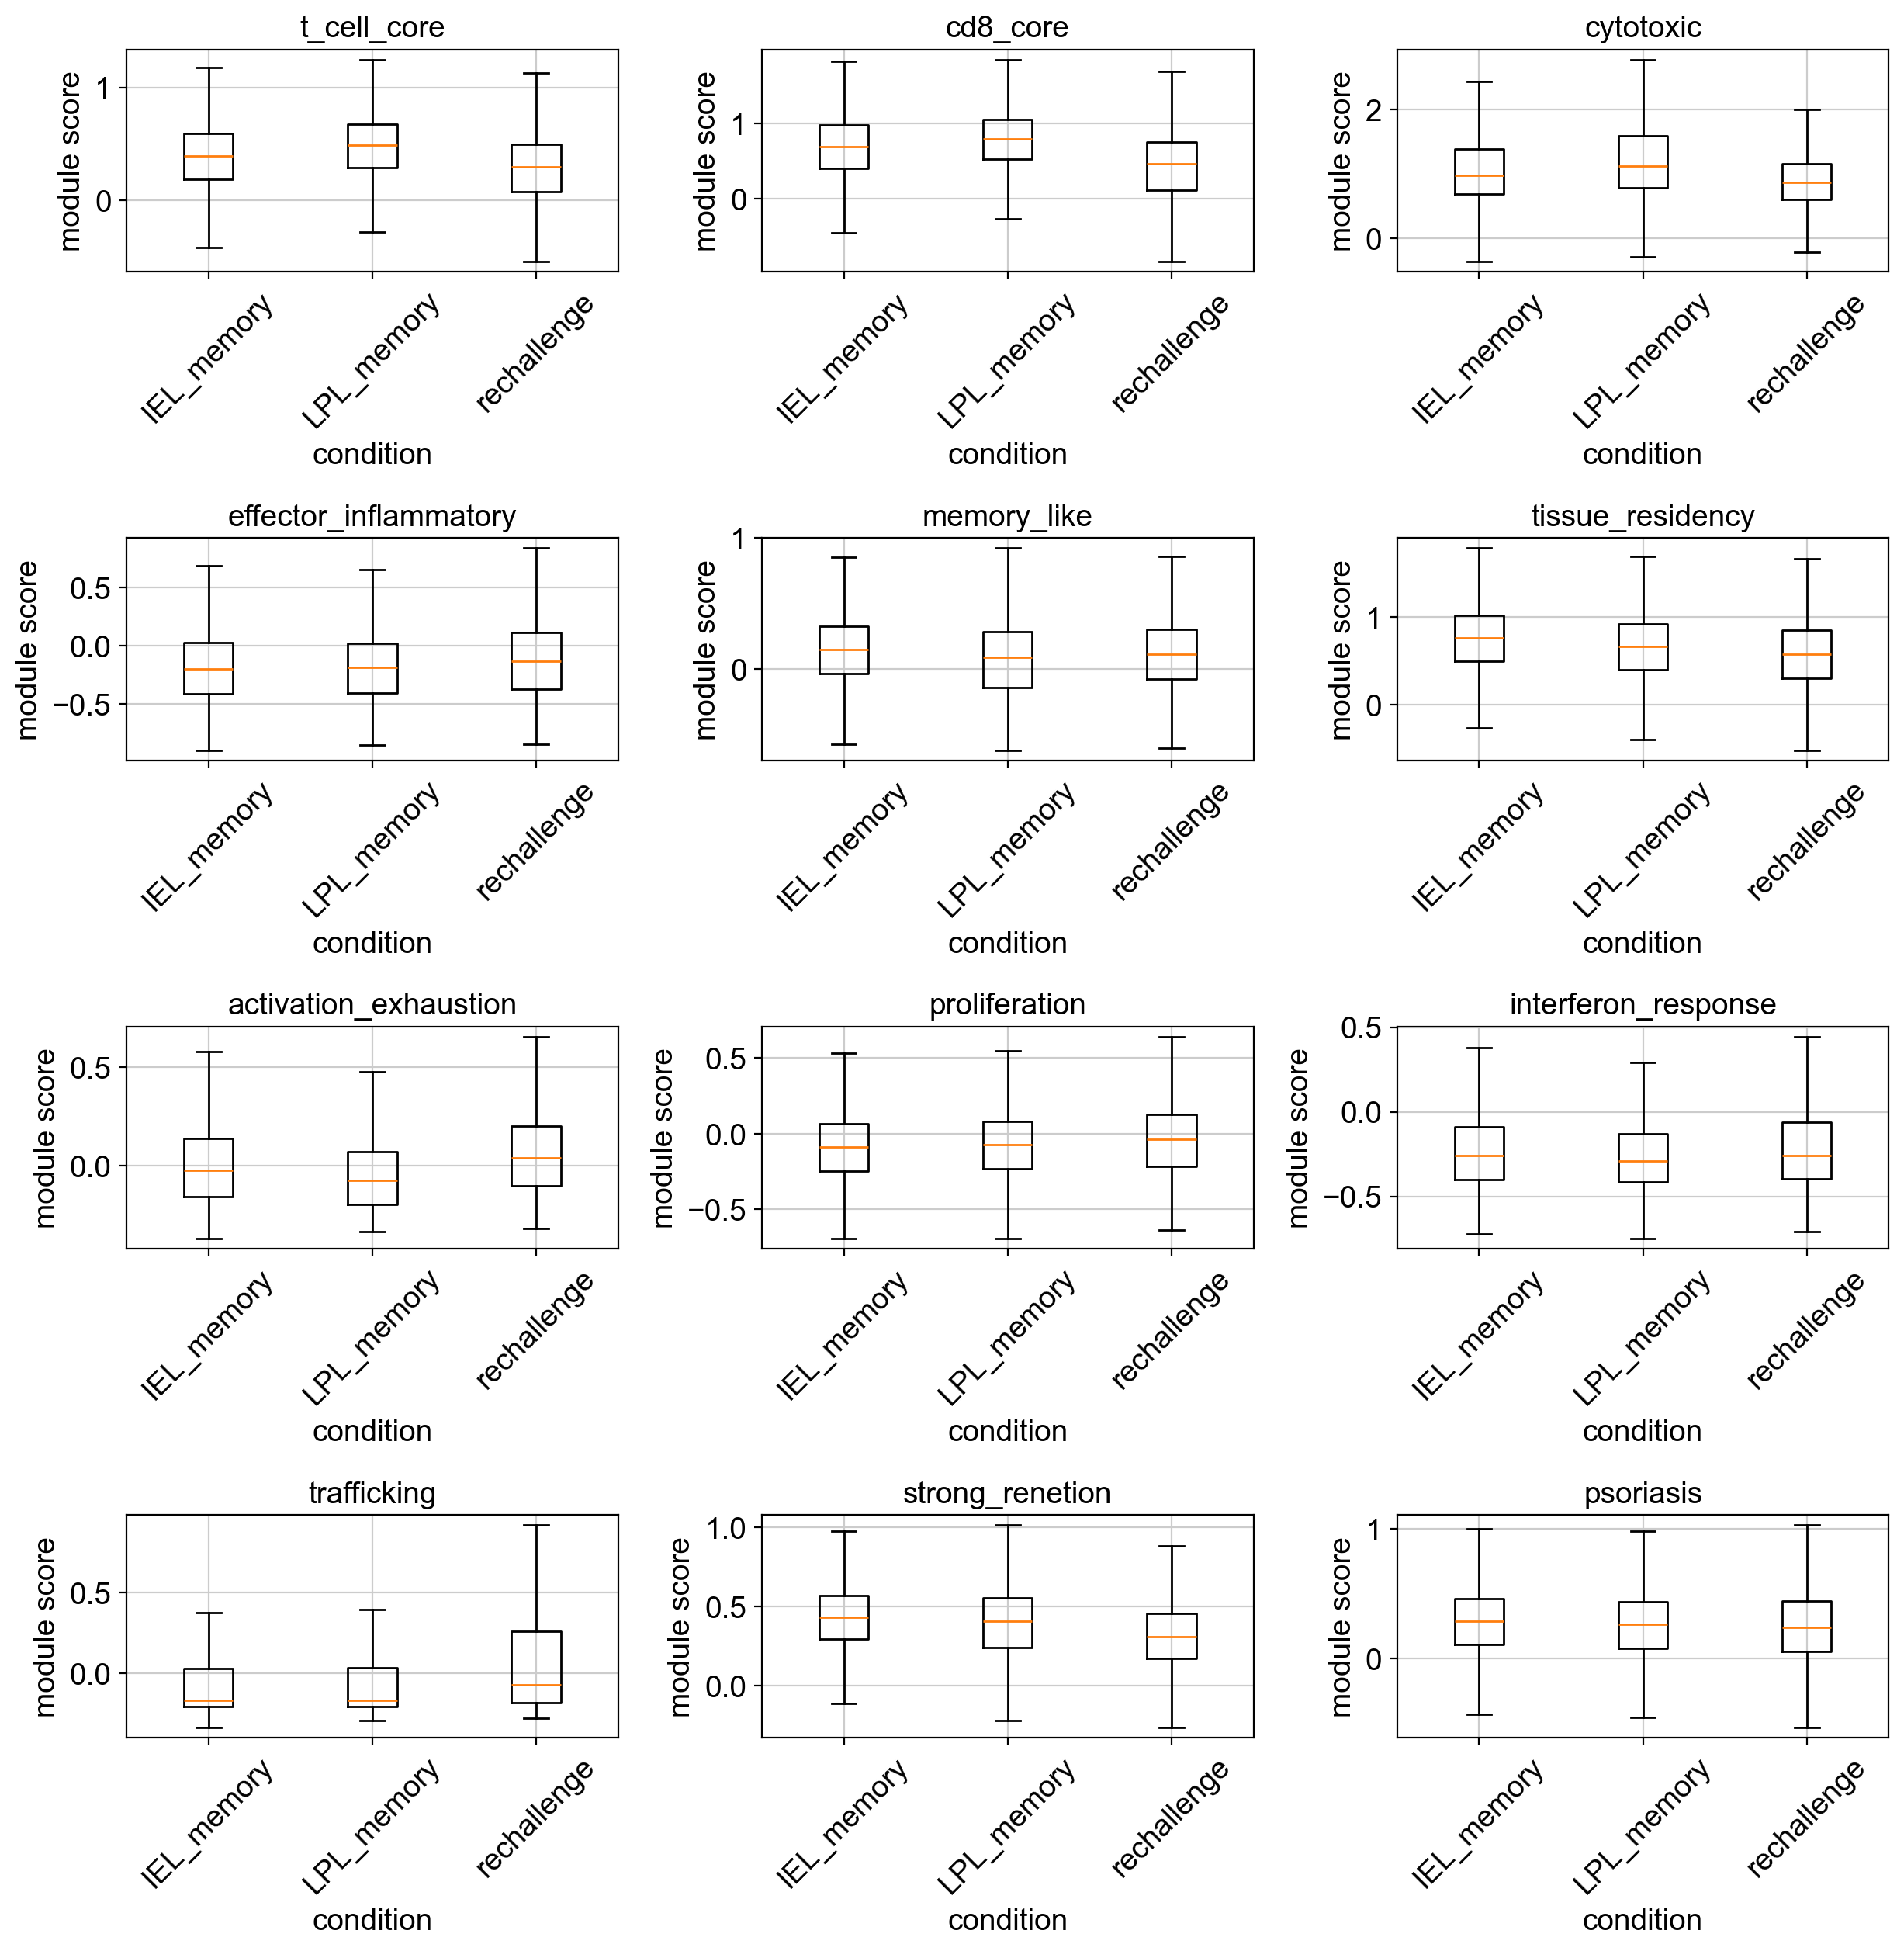

In [60]:
n_modules = len(score_columns)
ncols = min(3, n_modules)
nrows = int(np.ceil(n_modules / ncols))
fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(4.2 * ncols, 3.2 * nrows), squeeze=False)

for ax, score_column in zip(axes.ravel(), score_columns):
    plot_df = score_adata.obs[[groupby, score_column]].dropna()
    groups = list(plot_df[groupby].cat.categories) if hasattr(plot_df[groupby].dtype, "categories") else sorted(plot_df[groupby].astype(str).unique())
    values = [plot_df.loc[plot_df[groupby].astype(str).eq(str(group)), score_column].values for group in groups]

    ax.boxplot(values, labels=[str(group) for group in groups], showfliers=False)
    ax.set_title(score_column.replace("module_score_", ""))
    ax.set_xlabel(groupby)
    ax.set_ylabel("module score")
    ax.tick_params(axis="x", rotation=45)

for ax in axes.ravel()[n_modules:]:
    ax.axis("off")

fig.tight_layout()
boxplot_file = RESULTS_DIR / f"{output_prefix}_boxplots_by_{safe_name(groupby)}.png"
fig.savefig(boxplot_file, dpi=300, bbox_inches="tight")
print("Saved:", boxplot_file)


## Optional Dotplot of Module Genes

Use this to inspect the underlying genes for the modules that were scored.


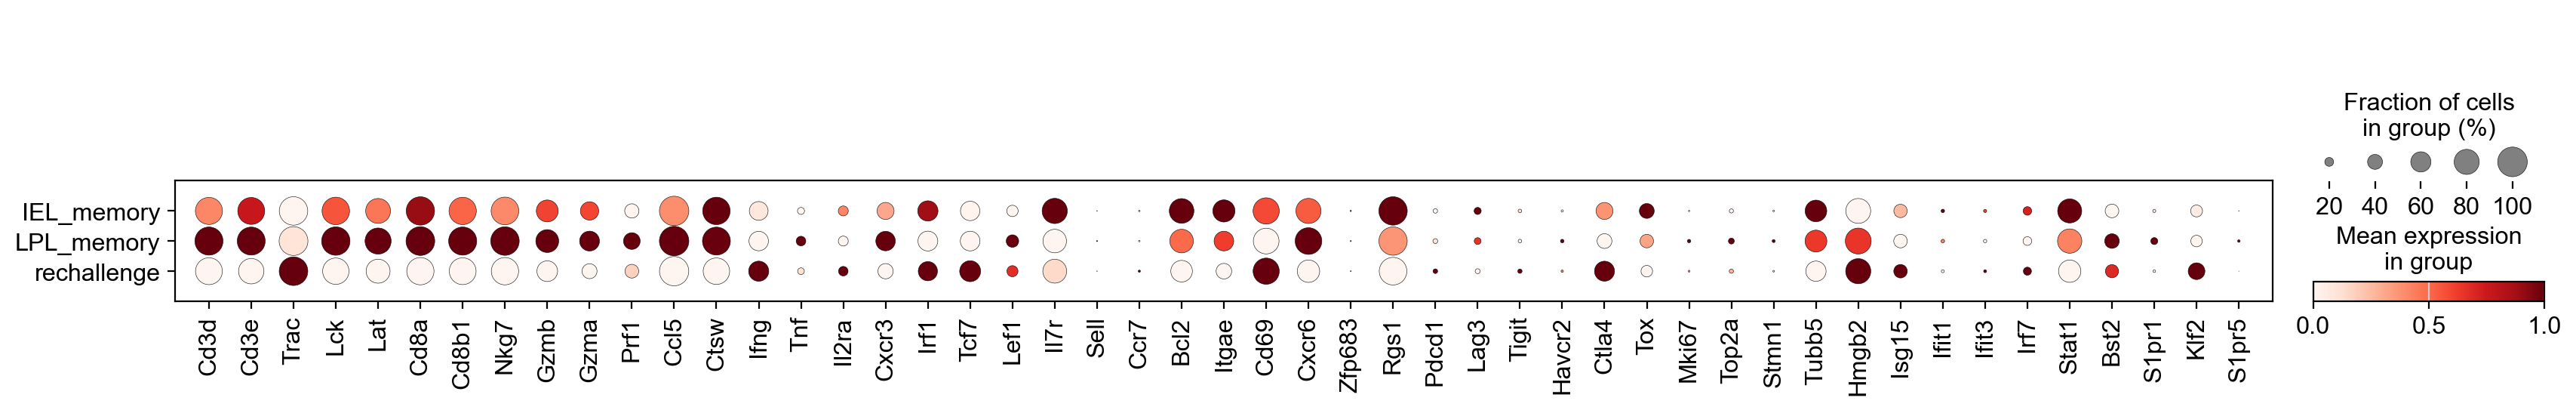

In [26]:
module_genes_present = []
for genes in modules.values():
    module_genes_present.extend([gene for gene in genes if gene in score_adata.var_names])
module_genes_present = list(dict.fromkeys(module_genes_present))

sc.pl.dotplot(
    score_adata,
    var_names=module_genes_present,
    groupby=groupby,
    use_raw=False,
    standard_scale="var",
)
